In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [3]:
#Load Dataset
df=pd.read_csv('/Users/tejasmac/ML Projects/Delhi NCR House Price Prediction/data/housing_cleaned.csv')

In [4]:
#Features
X=df[["bhk","area_sqft","parking"]]
y=df["price"]

In [5]:
#Train-Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
#Polynomial_Regression
poly=PolynomialFeatures(include_bias=False,degree=2)

X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

print(poly.get_feature_names_out())

['bhk' 'area_sqft' 'parking' 'bhk^2' 'bhk area_sqft' 'bhk parking'
 'area_sqft^2' 'area_sqft parking' 'parking^2']


In [11]:
poly_model=LinearRegression()

poly_model.fit(X_train_poly,y_train)
print("Poly Model trained successfully!✅")

Poly Model trained successfully!✅


In [13]:
poly_pred=poly_model.predict(X_test_poly)

In [17]:
#MAE
mae=mean_absolute_error(y_test,poly_pred)
print(f"MAE: ₹{mae/1e7:.2f} Cr")

#MSE
mse=mean_squared_error(y_test,poly_pred)
print(f"MSE: {mse}")

#RMSE
rmse=np.sqrt(mse)
print(f"RMSE: ₹{rmse/1e7:.2f} Cr")

#R2 Score
r2=r2_score(y_test,poly_pred)
print(f"R2 Score: {r2:.2f}")


MAE: ₹1.30 Cr
MSE: 586328524471482.5
RMSE: ₹2.42 Cr
R2 Score: 0.66


In [19]:
#Degree Tuning

results=[]
CRORE=1e7

degrees=[1,2,3,4,5]

for n in degrees:
    poly=PolynomialFeatures(include_bias=False,degree=n)

    X_train_poly=poly.fit_transform(X_train)
    X_test_poly=poly.transform(X_test)

    model=LinearRegression()
    model.fit(X_train_poly,y_train)

    current_pred=model.predict(X_test_poly)

    mae=mean_absolute_error(y_test,current_pred)/CRORE
    rmse=np.sqrt(mean_squared_error(y_test,current_pred))/CRORE
    r2=r2_score(y_test,current_pred)

    results.append([n,mae,rmse,r2])

results=pd.DataFrame(results,columns=["Degree","MAE (₹Cr)", "RMSE (₹Cr)","R²" ])
results=results.round(2)

print(results)

   Degree  MAE (₹Cr)  RMSE (₹Cr)    R²
0       1       1.72        3.06  0.46
1       2       1.30        2.42  0.66
2       3       2.37        4.00  0.07
3       4       2.44        4.16  0.00
4       5       2.45        4.16 -0.00


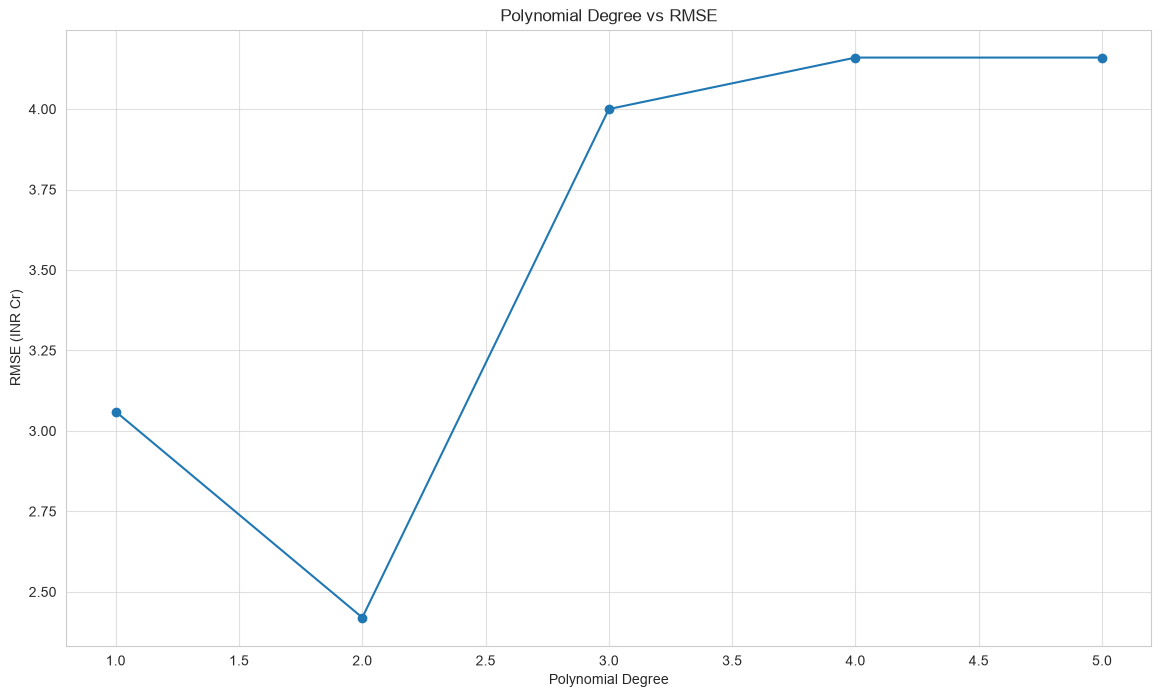

In [25]:
#Degree Graph
plt.figure(figsize=(14,8))

plt.plot(results["Degree"], results["RMSE (₹Cr)"], marker="o")

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE (INR Cr)")
plt.title("Polynomial Degree vs RMSE")

plt.grid(True,alpha=0.6)

plt.savefig("../outputs/plots/polydegree_vs_rmse.png", dpi=300)


plt.show()

In [26]:
import joblib

joblib.dump(poly_model, "../models/polynomial_regression_model.pkl")

['../models/polynomial_regression_model.pkl']